# Transformers and Time-Series Foundation Models

## 1. Why This Is the Final Notebook in the Folder

The forecasting progression so far has moved through:

```text
Dense
→ CNN
→ RNN / LSTM / GRU
→ TCN
→ Multivariate / Multi-Step Forecasting
```

This notebook adds two modern directions:

```text
Transformer-based forecasting
        ↓
Pretrained time-series foundation models
```

we focus on:

> How is attention adapted to a forecasting problem, and how does a pretrained temporal foundation model change the traditional train-a-model-for-each-dataset workflow?

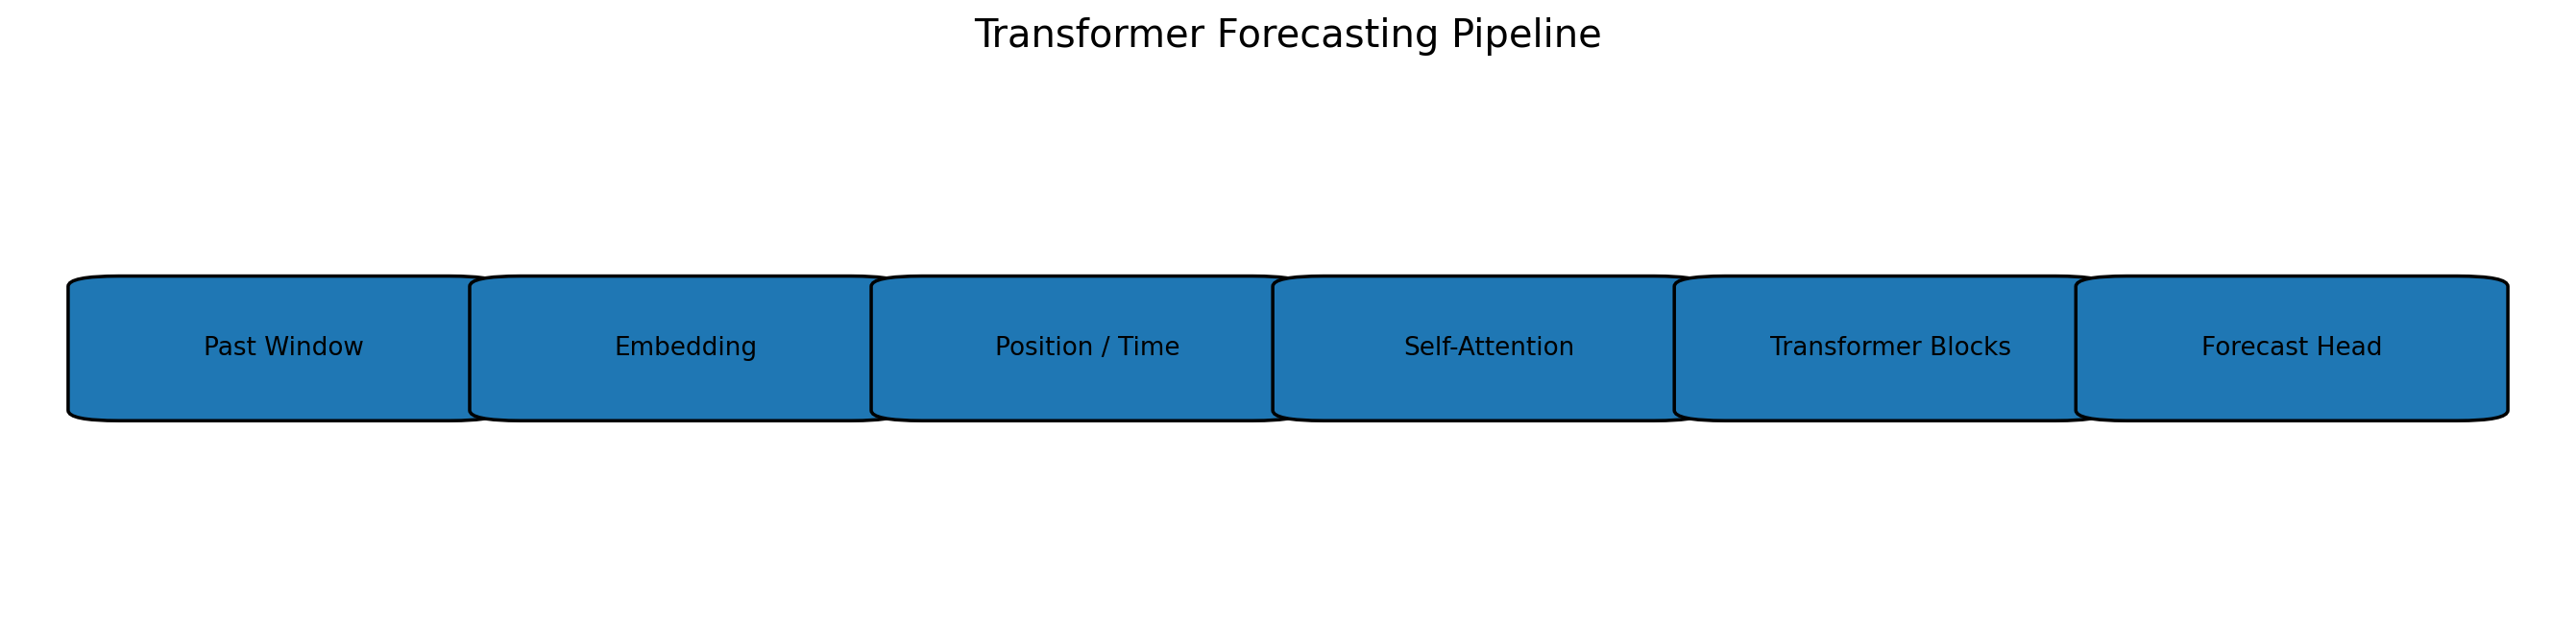

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain how a Transformer can encode a historical time-series window,
- understand temporal input projection and positional information,
- explain why a historical-context encoder does not necessarily require causal masking,
- build a Transformer forecasting model with PyTorch,
- understand patch-based temporal modeling,
- build a small patch Transformer,
- compare Transformer forecasts against a seasonal baseline,
- define a time-series foundation model,
- distinguish task-specific training from zero-shot forecasting,
- understand context length and forecast horizon,
- interpret point and quantile forecasts,
- run a zero-shot TimesFM example when the package and checkpoint are available,
- compare a trained model with a pretrained foundation-model workflow,
- discuss limitations, distribution shift, compute cost, and evaluation fairness.

## 3. Transformer Forecasting Pipeline

A basic forecasting Transformer can use:

```text
Historical values
      ↓
Input projection
      ↓
Positional information
      ↓
Self-attention
      ↓
Transformer encoder blocks
      ↓
Historical representation
      ↓
Forecast head
      ↓
Future values
```

## 4. A Subtle Point: Do We Need a Causal Mask?

For an autoregressive language model, causal masking prevents a token from seeing future tokens.

In this forecasting setup, the Transformer receives **only historical context**:

```text
[t-71, ..., t]
```

and predicts:

```text
[t+1, ..., t+24]
```

Every input position is already in the past relative to every forecast target.

Therefore, an encoder can allow attention across the complete historical window without leaking future target values.

A causal mask becomes necessary if the training formulation includes future positions inside the same sequence or performs autoregressive decoding.

## 5. Imports and Reproducibility

In [4]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

np.random.seed(42)

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(
    device
)

Device:
cpu


## 6. Load the Dataset

In [5]:
"""data_path = "data/synthetic_hourly_demand.csv"

data = pd.read_csv(
    data_path
)

data["timestamp"] = pd.to_datetime(
    data["timestamp"]
)

data = data.set_index(
    "timestamp"
)

series = data[
    "demand"
].copy()

print("Series length:")
print(
    len(
        series
    )
)"""

'data_path = "data/synthetic_hourly_demand.csv"\n\ndata = pd.read_csv(\n    data_path\n)\n\ndata["timestamp"] = pd.to_datetime(\n    data["timestamp"]\n)\n\ndata = data.set_index(\n    "timestamp"\n)\n\nseries = data[\n    "demand"\n].copy()\n\nprint("Series length:")\nprint(\n    len(\n        series\n    )\n)'

In [6]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.set_index("timestamp")

series = data["demand"].copy()

print("Series length:")
print(len(series))

Saving synthetic_hourly_demand.csv to synthetic_hourly_demand.csv
Series length:
4320


## 7. Define the Forecasting Task

We keep the same problem used in the multi-step notebook:

```text
lookback = 72 hours
forecast horizon = 24 hours
```

In [7]:
lookback = 72

forecast_horizon = 24

print("Lookback:")
print(
    lookback
)

print()

print("Forecast horizon:")
print(
    forecast_horizon
)

Lookback:
72

Forecast horizon:
24


## 8. Chronological Split and Scaling

In [8]:
number_of_rows = len(
    series
)

train_end = int(
    number_of_rows * 0.70
)

validation_end = int(
    number_of_rows * 0.85
)

train_series = series.iloc[
    :train_end
]

validation_series = series.iloc[
    train_end:validation_end
]

test_series = series.iloc[
    validation_end:
]

train_mean = train_series.mean()

train_std = train_series.std()

train_scaled = (
    train_series - train_mean
) / train_std

validation_scaled = (
    validation_series - train_mean
) / train_std

test_scaled = (
    test_series - train_mean
) / train_std

print("Training mean:")
print(
    train_mean
)

print()

print("Training standard deviation:")
print(
    train_std
)

Training mean:
58.131815796315834

Training standard deviation:
7.436389347851541


## 9. Build Multi-Step Windows

In [9]:
def create_multistep_windows(
    values,
    lookback,
    forecast_horizon
):

    X = []

    y = []

    maximum_start = (
        len(
            values
        )
        - lookback
        - forecast_horizon
        + 1
    )

    for start_index in range(
        maximum_start
    ):

        input_end = (
            start_index
            + lookback
        )

        target_end = (
            input_end
            + forecast_horizon
        )

        input_window = values[
            start_index:input_end
        ]

        target_window = values[
            input_end:target_end
        ]

        X.append(
            input_window
        )

        y.append(
            target_window
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    X = X[
        :,
        :,
        None
    ]

    return X, y

In [10]:
X_train, y_train = create_multistep_windows(
    train_scaled.to_numpy(),
    lookback,
    forecast_horizon
)

X_validation, y_validation = create_multistep_windows(
    validation_scaled.to_numpy(),
    lookback,
    forecast_horizon
)

X_test, y_test = create_multistep_windows(
    test_scaled.to_numpy(),
    lookback,
    forecast_horizon
)

print("Training X shape:")
print(
    X_train.shape
)

print()

print("Training y shape:")
print(
    y_train.shape
)

Training X shape:
(2929, 72, 1)

Training y shape:
(2929, 24)


## 10. DataLoaders

In [11]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_train
        ),
        torch.tensor(
            y_train
        )
    ),
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_validation
        ),
        torch.tensor(
            y_validation
        )
    ),
    batch_size=batch_size,
    shuffle=False
)

# Part I — Transformer Forecasting

## 11. Input Projection

Each timestep initially contains one scalar demand value.

The Transformer expects a vector representation of dimension:

```text
d_model
```

So we learn a projection:

\[
R^1
ightarrow R^{d_{model}}
\]

## 12. Positional Information

Self-attention alone does not inherently know temporal order.

We therefore add a learned positional embedding for:

```text
position 0
position 1
...
position 71
```

inside the historical window.

In [12]:
class TransformerForecaster(
    nn.Module
):

    def __init__(
        self,
        lookback,
        forecast_horizon,
        d_model=64,
        number_of_heads=4,
        number_of_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.lookback = lookback

        self.input_projection = nn.Linear(
            1,
            d_model
        )

        self.position_embedding = nn.Embedding(
            lookback,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=number_of_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=number_of_layers
        )

        self.output_layer = nn.Linear(
            d_model,
            forecast_horizon
        )


    def forward(
        self,
        x
    ):

        batch_size = x.size(
            0
        )

        positions = torch.arange(
            self.lookback,
            device=x.device
        )

        positions = positions.unsqueeze(
            0
        )

        positions = positions.expand(
            batch_size,
            self.lookback
        )

        x = self.input_projection(
            x
        )

        positional_vectors = self.position_embedding(
            positions
        )

        x = (
            x
            + positional_vectors
        )

        encoded = self.transformer_encoder(
            x
        )

        final_representation = encoded[
            :,
            -1,
            :
        ]

        forecast = self.output_layer(
            final_representation
        )

        return forecast

## 13. Inspect the Transformer

In [13]:
transformer_model = TransformerForecaster(
    lookback=lookback,
    forecast_horizon=forecast_horizon
)

transformer_model = transformer_model.to(
    device
)

print(
    transformer_model
)

TransformerForecaster(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (position_embedding): Embedding(72, 64)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=24, bias=True)
)


## 14. Inspect a Forward Pass

In [14]:
example_input = torch.tensor(
    X_train[
        :8
    ]
).to(
    device
)

with torch.no_grad():

    example_forecast = transformer_model(
        example_input
    )

print("Input shape:")
print(
    example_input.shape
)

print()

print("Forecast shape:")
print(
    example_forecast.shape
)

Input shape:
torch.Size([8, 72, 1])

Forecast shape:
torch.Size([8, 24])


## 15. Parameter Count

In [15]:
def count_parameters(
    model
):

    total = 0

    for parameter in model.parameters():

        total = (
            total
            + parameter.numel()
        )

    return total


print("Transformer parameters:")
print(
    count_parameters(
        transformer_model
    )
)

Transformer parameters:
73240


## 16. Train the Transformer

In [16]:
def train_model(
    model,
    train_loader,
    validation_loader,
    number_of_epochs=15
):

    model = model.to(
        device
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    training_losses = []

    validation_losses = []

    start_time = time.time()

    for epoch in range(
        number_of_epochs
    ):

        model.train()

        training_sum = 0.0

        training_batches = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            optimizer.step()

            training_sum = (
                training_sum
                + loss.item()
            )

            training_batches = (
                training_batches
                + 1
            )

        average_training_loss = (
            training_sum
            / training_batches
        )

        model.eval()

        validation_sum = 0.0

        validation_batches = 0

        with torch.no_grad():

            for X_batch, y_batch in validation_loader:

                X_batch = X_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                predictions = model(
                    X_batch
                )

                loss = criterion(
                    predictions,
                    y_batch
                )

                validation_sum = (
                    validation_sum
                    + loss.item()
                )

                validation_batches = (
                    validation_batches
                    + 1
                )

        average_validation_loss = (
            validation_sum
            / validation_batches
        )

        training_losses.append(
            average_training_loss
        )

        validation_losses.append(
            average_validation_loss
        )

        print(
            "Epoch:",
            epoch + 1,
            "| Train:",
            round(
                average_training_loss,
                5
            ),
            "| Validation:",
            round(
                average_validation_loss,
                5
            )
        )

    training_time = (
        time.time()
        - start_time
    )

    return (
        model,
        training_losses,
        validation_losses,
        training_time
    )

In [17]:
transformer_model, transformer_train_loss, transformer_val_loss, transformer_training_time = train_model(
    transformer_model,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.63193 | Validation: 0.38009
Epoch: 2 | Train: 0.21798 | Validation: 0.24699
Epoch: 3 | Train: 0.17759 | Validation: 0.19599
Epoch: 4 | Train: 0.16455 | Validation: 0.21564
Epoch: 5 | Train: 0.15572 | Validation: 0.21661
Epoch: 6 | Train: 0.14659 | Validation: 0.17597
Epoch: 7 | Train: 0.13497 | Validation: 0.13821
Epoch: 8 | Train: 0.13085 | Validation: 0.13827
Epoch: 9 | Train: 0.12608 | Validation: 0.16765
Epoch: 10 | Train: 0.12135 | Validation: 0.13134
Epoch: 11 | Train: 0.11774 | Validation: 0.12834
Epoch: 12 | Train: 0.1147 | Validation: 0.13702
Epoch: 13 | Train: 0.11152 | Validation: 0.15085
Epoch: 14 | Train: 0.11114 | Validation: 0.13572
Epoch: 15 | Train: 0.11183 | Validation: 0.11079


## 17. Plot Transformer Learning Curves

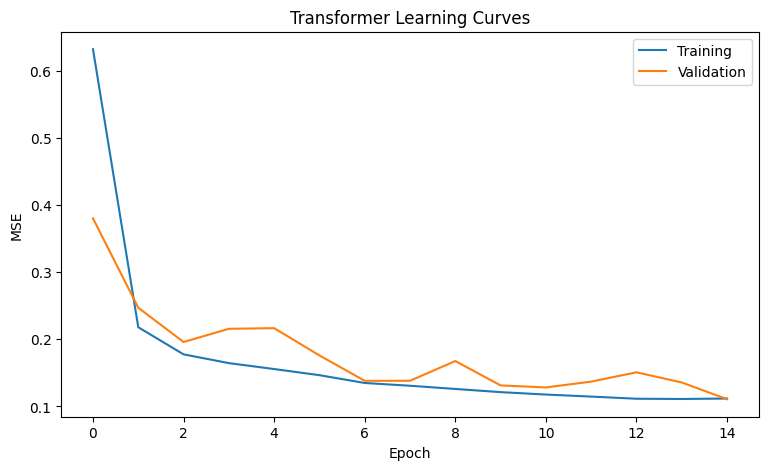

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    transformer_train_loss,
    label="Training"
)

plt.plot(
    transformer_val_loss,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Transformer Learning Curves")
plt.legend()

plt.show()

## 18. Generate Transformer Test Forecasts

In [19]:
transformer_model.eval()

X_test_tensor = torch.tensor(
    X_test
).to(
    device
)

with torch.no_grad():

    transformer_scaled = transformer_model(
        X_test_tensor
    )

transformer_scaled = transformer_scaled.cpu().numpy()

actual_test = (
    y_test
    * train_std
    + train_mean
)

transformer_predictions = (
    transformer_scaled
    * train_std
    + train_mean
)

## 19. Seasonal-Naive Multi-Step Baseline

In [20]:
seasonal_naive_scaled = X_test[
    :,
    -24:,
    0
]

seasonal_naive_predictions = (
    seasonal_naive_scaled
    * train_std
    + train_mean
)

## 20. Evaluate the Transformer

In [21]:
def calculate_mae(
    actual,
    predicted
):

    return np.mean(
        np.abs(
            actual - predicted
        )
    )


def calculate_rmse(
    actual,
    predicted
):

    return np.sqrt(
        np.mean(
            (
                actual - predicted
            ) ** 2
        )
    )

In [22]:
transformer_mae = calculate_mae(
    actual_test,
    transformer_predictions
)

transformer_rmse = calculate_rmse(
    actual_test,
    transformer_predictions
)

seasonal_mae = calculate_mae(
    actual_test,
    seasonal_naive_predictions
)

seasonal_rmse = calculate_rmse(
    actual_test,
    seasonal_naive_predictions
)

comparison = pd.DataFrame(
    [
        {
            "Model": "Seasonal Naive",
            "MAE": seasonal_mae,
            "RMSE": seasonal_rmse
        },
        {
            "Model": "Transformer",
            "MAE": transformer_mae,
            "RMSE": transformer_rmse
        }
    ]
)

print(
    comparison
)

            Model       MAE      RMSE
0  Seasonal Naive  2.796419  3.456763
1     Transformer  2.287843  2.854338


## 21. Horizon-Wise Transformer Error

In [23]:
horizon_numbers = np.arange(
    1,
    forecast_horizon + 1
)

transformer_horizon_mae = []

seasonal_horizon_mae = []

for horizon_index in range(
    forecast_horizon
):

    transformer_horizon_mae.append(
        calculate_mae(
            actual_test[
                :,
                horizon_index
            ],
            transformer_predictions[
                :,
                horizon_index
            ]
        )
    )

    seasonal_horizon_mae.append(
        calculate_mae(
            actual_test[
                :,
                horizon_index
            ],
            seasonal_naive_predictions[
                :,
                horizon_index
            ]
        )
    )

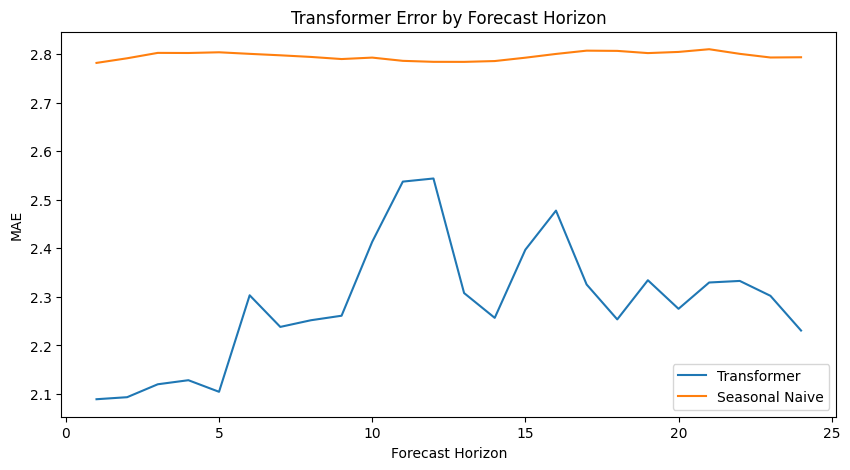

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizon_numbers,
    transformer_horizon_mae,
    label="Transformer"
)

plt.plot(
    horizon_numbers,
    seasonal_horizon_mae,
    label="Seasonal Naive"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("Transformer Error by Forecast Horizon")
plt.legend()

plt.show()

# Part II — Patch-Based Time-Series Modeling

## 22. Why Use Patches?

A long temporal context creates many attention positions.

Instead of treating every timestamp independently, group nearby values into patches.

Example:

```text
72 hourly points

patch size = 6

72 / 6 = 12 temporal patches
```

Self-attention then operates over 12 patch tokens instead of 72 individual timestamps.

## 23. Patch Representation

Each patch contains several consecutive values:

```text
[x1, x2, x3, x4, x5, x6]
```

A learned linear layer maps this patch to one Transformer embedding.

In [25]:
patch_size = 6

number_of_patches = (
    lookback
    // patch_size
)

print("Patch size:")
print(
    patch_size
)

print()

print("Number of patches:")
print(
    number_of_patches
)

Patch size:
6

Number of patches:
12


## 24. Reshape One Example Into Patches

In [26]:
example_series = X_train[
    0,
    :,
    0
]

patches = example_series.reshape(
    number_of_patches,
    patch_size
)

print("Original sequence shape:")
print(
    example_series.shape
)

print()

print("Patch matrix shape:")
print(
    patches.shape
)

print()

print("First patch:")
print(
    patches[
        0
    ]
)

Original sequence shape:
(72,)

Patch matrix shape:
(12, 6)

First patch:
[-0.06107312 -0.38787982  0.34449786  0.18211772  0.4206239  -0.10528501]


## 25. Build a Patch Transformer

In [27]:
class PatchTransformerForecaster(
    nn.Module
):

    def __init__(
        self,
        lookback,
        patch_size,
        forecast_horizon,
        d_model=64,
        number_of_heads=4
    ):
        super().__init__()

        self.patch_size = patch_size

        self.number_of_patches = (
            lookback
            // patch_size
        )

        self.patch_projection = nn.Linear(
            patch_size,
            d_model
        )

        self.position_embedding = nn.Embedding(
            self.number_of_patches,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=number_of_heads,
            dim_feedforward=128,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.output_layer = nn.Linear(
            d_model,
            forecast_horizon
        )


    def forward(
        self,
        x
    ):

        x = x.squeeze(
            2
        )

        batch_size = x.size(
            0
        )

        x = x.reshape(
            batch_size,
            self.number_of_patches,
            self.patch_size
        )

        x = self.patch_projection(
            x
        )

        positions = torch.arange(
            self.number_of_patches,
            device=x.device
        )

        positions = positions.unsqueeze(
            0
        )

        positions = positions.expand(
            batch_size,
            self.number_of_patches
        )

        x = (
            x
            + self.position_embedding(
                positions
            )
        )

        encoded = self.encoder(
            x
        )

        pooled = encoded.mean(
            dim=1
        )

        forecast = self.output_layer(
            pooled
        )

        return forecast

## 26. Train the Patch Transformer

In [28]:
patch_transformer = PatchTransformerForecaster(
    lookback=lookback,
    patch_size=patch_size,
    forecast_horizon=forecast_horizon
)

patch_transformer, patch_train_loss, patch_val_loss, patch_training_time = train_model(
    patch_transformer,
    train_loader,
    validation_loader
)

Epoch: 1 | Train: 0.52276 | Validation: 0.26101
Epoch: 2 | Train: 0.15158 | Validation: 0.16463
Epoch: 3 | Train: 0.11843 | Validation: 0.13108
Epoch: 4 | Train: 0.10782 | Validation: 0.14251
Epoch: 5 | Train: 0.10608 | Validation: 0.13739
Epoch: 6 | Train: 0.10128 | Validation: 0.12367
Epoch: 7 | Train: 0.1019 | Validation: 0.11628
Epoch: 8 | Train: 0.10015 | Validation: 0.11075
Epoch: 9 | Train: 0.09727 | Validation: 0.11261
Epoch: 10 | Train: 0.09738 | Validation: 0.11373
Epoch: 11 | Train: 0.09687 | Validation: 0.107
Epoch: 12 | Train: 0.09552 | Validation: 0.11096
Epoch: 13 | Train: 0.09499 | Validation: 0.10182
Epoch: 14 | Train: 0.09454 | Validation: 0.1074
Epoch: 15 | Train: 0.09469 | Validation: 0.10563


## 27. Evaluate the Patch Transformer

In [29]:
patch_transformer.eval()

with torch.no_grad():

    patch_scaled = patch_transformer(
        X_test_tensor
    )

patch_scaled = patch_scaled.cpu().numpy()

patch_predictions = (
    patch_scaled
    * train_std
    + train_mean
)

patch_mae = calculate_mae(
    actual_test,
    patch_predictions
)

patch_rmse = calculate_rmse(
    actual_test,
    patch_predictions
)

print("Patch Transformer MAE:")
print(
    patch_mae
)

print()

print("Patch Transformer RMSE:")
print(
    patch_rmse
)

Patch Transformer MAE:
2.2784066666646896

Patch Transformer RMSE:
2.831601145934268


## 28. Point Transformer vs Patch Transformer

Patching introduces a trade-off.

### Advantages

- fewer attention positions,
- lower attention cost,
- local patterns grouped into compact tokens,
- longer context can become more manageable.

### Limitations

- some fine-grained temporal detail may be compressed,
- patch size becomes another hyperparameter,
- alignment with natural seasonal periods can matter.

# Part III — Time-Series Foundation Models

## 29. What Is a Time-Series Foundation Model?

A conventional forecasting workflow is:

```text
one dataset
    ↓
train one model
    ↓
use on that domain
```

A time-series foundation model changes the idea:

```text
many diverse time series
        ↓
large-scale pretraining
        ↓
general temporal model
        ↓
new unseen series
        ↓
zero-shot / few-shot forecast
```

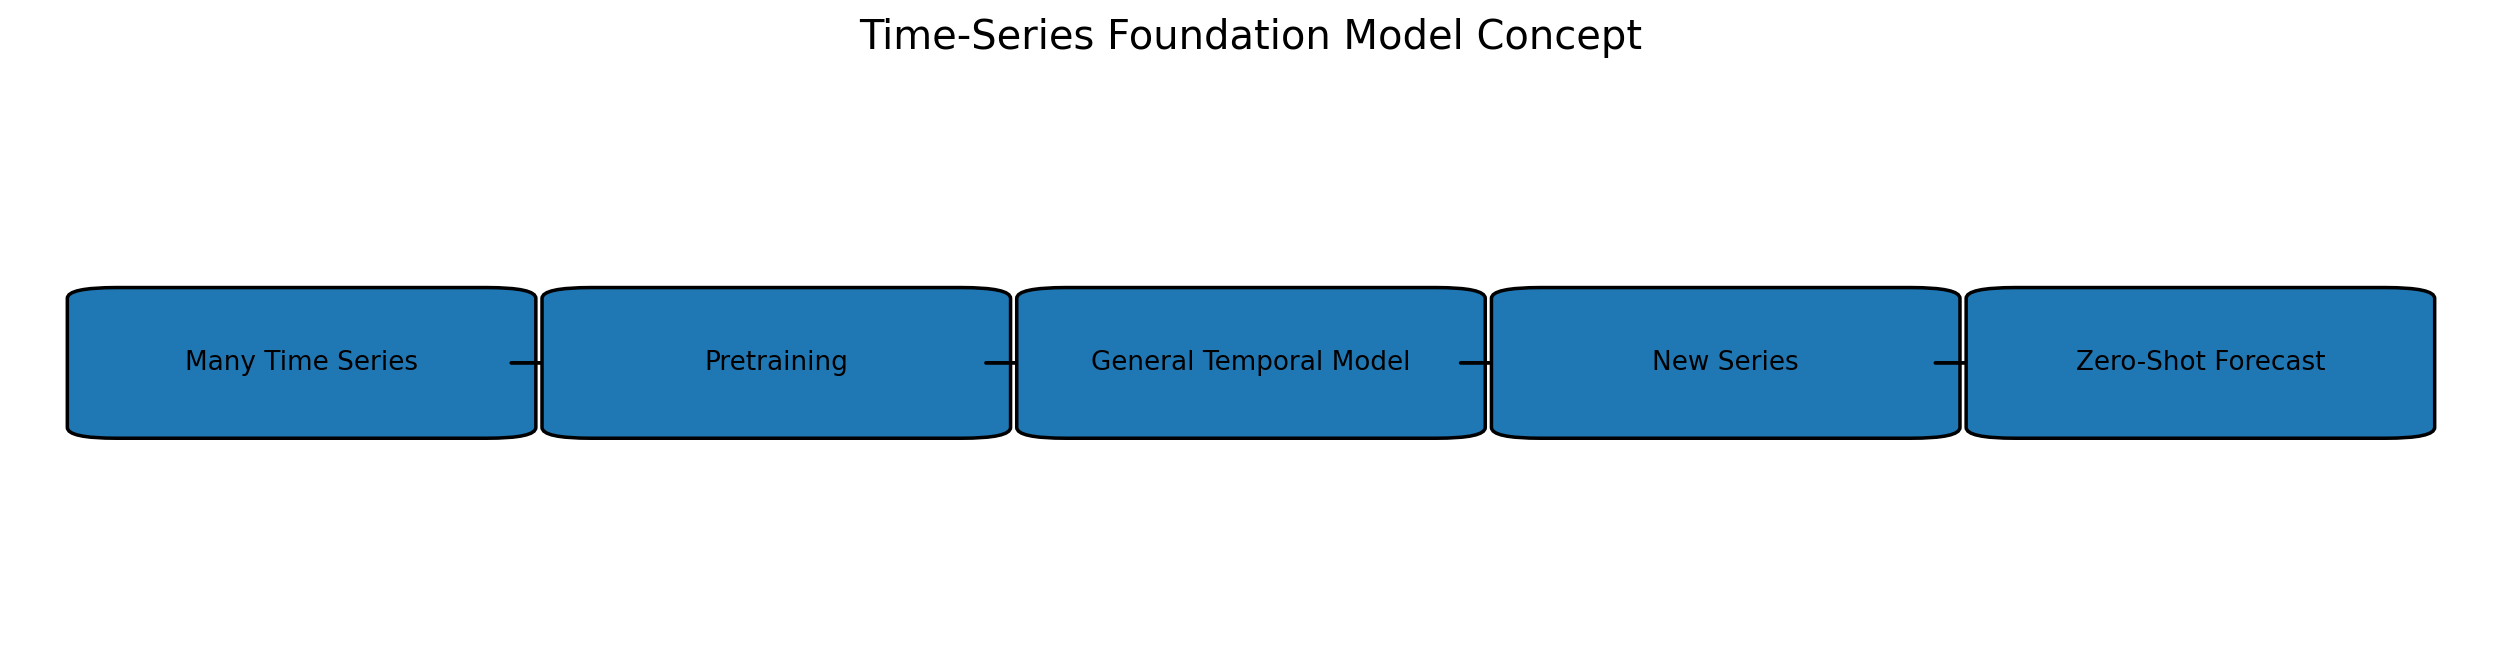

## 30. What Does Zero-Shot Forecasting Mean?

Zero-shot forecasting means:

> Use a pretrained model on a new target series without fitting the model weights to that specific forecasting dataset.

The user provides:

```text
historical context
forecast horizon
```

and the pretrained model returns future predictions.

## 31. Foundation Models Do Not Remove Forecasting Discipline

Even with a pretrained model, we still need:

- valid historical context,
- chronological evaluation,
- consistent forecast horizon,
- fair baselines,
- appropriate metrics,
- awareness of future covariates,
- distribution-shift analysis.

A foundation model changes the **model-training workflow**, not the rules of valid forecasting evaluation.

## 32. Examples of Time-Series Foundation Model Families

Examples include:

- **TimesFM**,
- **Chronos**,
- other pretrained general-purpose temporal forecasting models.

This portfolio uses **TimesFM** for the practical zero-shot example because it provides a direct connection between pretrained temporal modeling and the earlier foundation-model concepts studied in the LLM portfolio.

## 33. Current TimesFM Note

Time-series foundation-model libraries evolve quickly.

The optional code below follows the **TimesFM 3.0-style API** available when this portfolio section was prepared.

Before running it in the future, check the official Google Research TimesFM repository for the current installation instructions and API.

This section is intentionally separated from the from-scratch Transformer implementation so an API change does not affect the educational core of the notebook.

## 34. Prepare a Zero-Shot Context

We choose one forecast origin.

The foundation model receives only the historical demand values before that origin.

In [30]:
full_demand = series.to_numpy(
    dtype=np.float32
)

test_start_index = validation_end

context_length = 512

forecast_origin = (
    test_start_index
    + 200
)

context_start = (
    forecast_origin
    - context_length
)

context_values = full_demand[
    context_start:forecast_origin
]

future_actual = full_demand[
    forecast_origin:
    forecast_origin
    + forecast_horizon
]

print("Context shape:")
print(
    context_values.shape
)

print()

print("Future actual shape:")
print(
    future_actual.shape
)

Context shape:
(512,)

Future actual shape:
(24,)


## 35. Seasonal-Naive Forecast at the Same Origin

In [31]:
seasonal_naive_foundation = full_demand[
    forecast_origin - 24:
    forecast_origin
]

print("Seasonal-naive shape:")
print(
    seasonal_naive_foundation.shape
)

Seasonal-naive shape:
(24,)


## 36. Optional TimesFM 3.0 Zero-Shot Forecast

Install the current TimesFM package following the official repository instructions before running this section.

The code is wrapped in `try/except` so the rest of the notebook remains runnable even when TimesFM is not installed.

In [32]:
timesfm_available = False

try:

    from timesfm3 import TimesFM3Evaluator
    from timesfm3 import ModelConfig

    timesfm_available = True

    print(
        "TimesFM 3.0 package is available."
    )

except ImportError:

    print(
        "TimesFM 3.0 is not installed in this environment."
    )

    print(
        "Follow the official TimesFM repository installation instructions, then rerun this section."
    )

TimesFM 3.0 is not installed in this environment.
Follow the official TimesFM repository installation instructions, then rerun this section.


## 37. Load the Pretrained Foundation Model

This cell runs only when the TimesFM 3.0 package is available.

A GPU is recommended for faster inference.

In [33]:
timesfm_forecaster = None

if timesfm_available:

    timesfm_device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    timesfm_config = ModelConfig(
        checkpoint_path="google/timesfm-3.0-pytorch",
        per_core_batch_size=8,
        device=timesfm_device
    )

    timesfm_forecaster = TimesFM3Evaluator(
        timesfm_config
    )

    print(
        "TimesFM forecaster loaded."
    )

## 38. Generate Point and Quantile Forecasts

A foundation model can return more than one point estimate.

Quantile forecasts describe uncertainty across the future horizon.

In [34]:
timesfm_point_forecast = None

timesfm_quantile_forecast = None

if timesfm_forecaster is not None:

    outputs = list(
        timesfm_forecaster.predict_batch(
            [
                context_values
            ],
            horizon=forecast_horizon,
            return_quantiles=True,
            use_symmetric_averaging=False
        )
    )

    timesfm_point_forecast = outputs[
        0
    ].forecast

    timesfm_quantile_forecast = outputs[
        0
    ].quantiles

    print("Point forecast shape:")
    print(
        timesfm_point_forecast.shape
    )

    print()

    print("Quantile forecast shape:")
    print(
        timesfm_quantile_forecast.shape
    )

## 39. Evaluate Zero-Shot TimesFM if Available

In [35]:
if timesfm_point_forecast is not None:

    timesfm_mae = calculate_mae(
        future_actual,
        timesfm_point_forecast
    )

    timesfm_rmse = calculate_rmse(
        future_actual,
        timesfm_point_forecast
    )

    seasonal_origin_mae = calculate_mae(
        future_actual,
        seasonal_naive_foundation
    )

    seasonal_origin_rmse = calculate_rmse(
        future_actual,
        seasonal_naive_foundation
    )

    zero_shot_comparison = pd.DataFrame(
        [
            {
                "Model": "Seasonal Naive",
                "MAE": seasonal_origin_mae,
                "RMSE": seasonal_origin_rmse
            },
            {
                "Model": "TimesFM Zero-Shot",
                "MAE": timesfm_mae,
                "RMSE": timesfm_rmse
            }
        ]
    )

    print(
        zero_shot_comparison
    )

## 40. Plot the Zero-Shot Forecast if Available

In [36]:
if timesfm_point_forecast is not None:

    horizon = np.arange(
        1,
        forecast_horizon + 1
    )

    plt.figure(figsize=(11, 5))

    plt.plot(
        horizon,
        future_actual,
        label="Actual",
        marker="o"
    )

    plt.plot(
        horizon,
        seasonal_naive_foundation,
        label="Seasonal Naive"
    )

    plt.plot(
        horizon,
        timesfm_point_forecast,
        label="TimesFM Zero-Shot"
    )

    plt.xlabel("Hours Ahead")
    plt.ylabel("Demand")
    plt.title("Zero-Shot Foundation-Model Forecast")
    plt.legend()

    plt.show()

## 41. Quantile Forecast Interpretation

If the model provides quantiles such as:

```text
q10
q50
q90
```

then the output is not only:

```text
one expected future path
```

It also communicates a range of plausible future outcomes.

This connects directly to the prediction-interval discussion from the Time Series Foundations folder.

## 42. Fair Foundation-Model Evaluation

One origin is useful for visualization but not enough for a serious comparison.

A stronger experiment should evaluate multiple forecast origins:

```text
Origin 1
Origin 2
...
Origin N
```

using the same:

- context length,
- horizon,
- test period,
- metrics,
- baseline definitions.

Then report average and horizon-wise errors.

## 43. Trained Model vs Foundation Model

### Task-Specific Transformer

```text
your dataset
→ train model weights
→ validation
→ test
```

### Foundation Model

```text
pretrained model
→ provide context
→ zero-shot forecast
```

The comparison is not only about MAE.

Also consider:

- task-specific training time,
- inference time,
- hardware requirements,
- parameter count,
- domain adaptation,
- zero-shot convenience,
- uncertainty output,
- reproducibility.

## 44. Few-Shot and Fine-Tuning Concepts

Foundation models can also be adapted.

Possible strategies include:

- longer in-context history,
- covariate conditioning,
- parameter-efficient fine-tuning,
- full fine-tuning where supported.

This parallels the progression studied in the LLM portfolio:

```text
pretrained model
→ zero-shot use
→ adaptation
```

but the data and objective are temporal rather than linguistic.

## 45. Distribution Shift

A pretrained time-series model has seen many temporal patterns, but a new domain may still differ.

Examples:

- unusual seasonality,
- physical regime changes,
- extreme events,
- sensor drift,
- policy changes,
- new operational constraints.

Zero-shot capability does not guarantee strong performance on every domain.

## 46. Why Foundation Models Are Not Automatically Better

A foundation model may lose to:

- seasonal naive,
- a domain-specific statistical model,
- a small LSTM,
- a specialized Transformer.

Reasons can include:

- mismatch between pretraining data and target domain,
- context limitations,
- unusual scale or frequency,
- rare exogenous drivers,
- insufficient covariate information.

The correct portfolio message is:

> Foundation models are powerful general-purpose baselines, not guaranteed winners.

## 47. Final Comparison Framework

A final applied forecasting project can compare:

| Model | Training Needed? | MAE | RMSE | Horizon Error | Training Time | Zero-Shot? |
|---|---|---:|---:|---:|---:|---|
| Seasonal Naive | No | | | | | Yes |
| Dense | Yes | | | | | No |
| 1D CNN | Yes | | | | | No |
| LSTM | Yes | | | | | No |
| GRU | Yes | | | | | No |
| TCN | Yes | | | | | No |
| Transformer | Yes | | | | | No |
| Patch Transformer | Yes | | | | | No |
| Time-Series Foundation Model | No for zero-shot | | | | | Yes |

This completes the learning progression from simple temporal assumptions to pretrained general-purpose forecasting models.

## 48. Limitations

This notebook does not attempt to reproduce a production-scale forecasting benchmark.

Limitations include:

- synthetic dataset,
- relatively small task-specific Transformer,
- fixed horizon,
- no hyperparameter optimization,
- one basic patching strategy,
- optional external foundation-model dependency,
- no comprehensive multi-origin foundation-model benchmark inside the default run.

These limitations are explicit so the notebook remains educational and reproducible.

## 49. Final Learning Progression

The complete **Deep Learning for Time Series Forecasting** folder now follows:

```text
Seasonal Baseline
        ↓
Dense Network
        ↓
1D CNN
        ↓
RNN
        ↓
LSTM
        ↓
GRU
        ↓
TCN
        ↓
Multivariate Forecasting
        ↓
Multi-Step Forecasting
        ↓
Transformer
        ↓
Patch-Based Transformer
        ↓
Time-Series Foundation Model
        ↓
Zero-Shot Forecasting
```

## 50. Key Takeaways

- Transformers can encode historical windows with self-attention.
- A historical-only encoder does not automatically need causal masking.
- Positional information is still required because temporal order matters.
- Patch-based modeling reduces the number of attention positions.
- Time-series foundation models are pretrained across many temporal datasets.
- Zero-shot forecasting removes task-specific weight training, not the need for rigorous evaluation.
- Point forecasts and quantile forecasts answer different questions.
- Foundation models should be compared with simple and task-specific baselines.
- Forecasting quality must be judged across horizons, not only by one aggregate score.